<a href="https://colab.research.google.com/github/kaybrian/ML_/blob/main/style%20transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow_hub as hub
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
model = hub.load("https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2")

In [5]:
# define a function to load images and preprocess them
def load_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = img[tf.newaxis, :]
    return img

In [14]:
# load up the images to the system
content_image = load_image("/content/download.jpeg")
style_image = load_image("/content/download (1).jpeg")

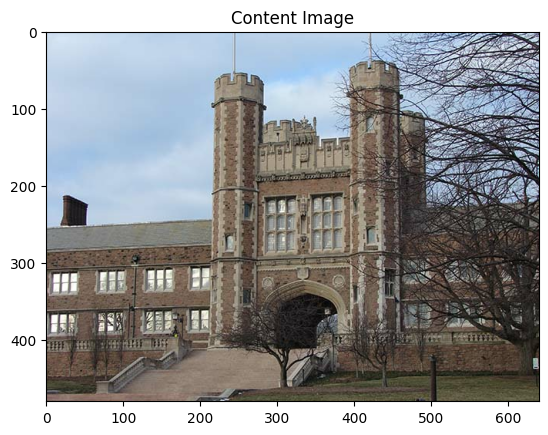

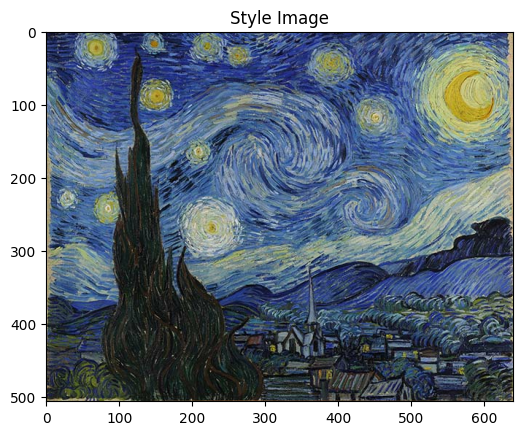

In [15]:
# show the outputs
plt.imshow(np.squeeze(content_image))
plt.title("Content Image")
plt.show()

plt.imshow(np.squeeze(style_image))
plt.title("Style Image")
plt.show()

In [16]:
style_image.shape

TensorShape([1, 507, 640, 3])

In [17]:
# preform a neural style transfer
stylized_image = model(tf.constant(content_image), tf.constant(style_image))[0]

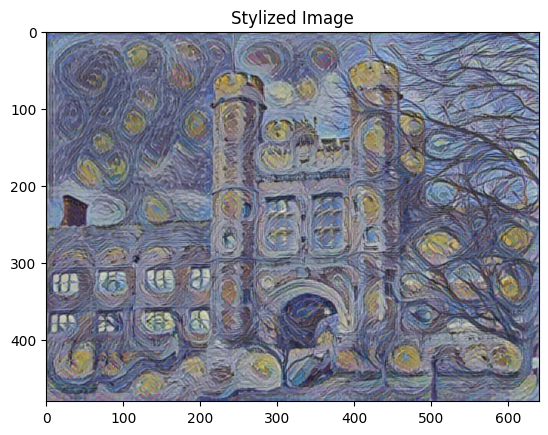

In [18]:
# show the genrated image
plt.imshow(np.squeeze(stylized_image))
plt.title("Stylized Image")
plt.show()